# Molecular Property Analysis — DiffSBDD Generated Molecules

This notebook analyzes the molecules generated by DiffSBDD targeting 
the A2A adenosine receptor (PDB: 4EIY).

DiffSBDD uses a 3D equivariant diffusion model to generate molecules 
by denoising all atoms simultaneously from Gaussian noise.

---
> **Input:** `outputs/diffsbdd/DiffSBDD_ligands.sdf` — raw SDFs from DiffSBDD SDF output
> **Output:** `results/diffsbdd_generated.csv` — with calculated molecular properties

## 1. Load Libraries

RDKit is used for cheminformatics calculations. Pandas for data handling, 
Matplotlib for visualization.

In [124]:
import pandas as pd                              # data handling and tables
from rdkit import Chem                           # molecule parsing from SMILES
from rdkit.Chem import Descriptors, QED          # MW, LogP, QED calculations
from rdkit.Chem import rdMolDescriptors          # HBA, HBD, TPSA, RotBonds
import matplotlib.pyplot as plt                  # plots and histograms
import warnings
warnings.filterwarnings('ignore')                # suppress RDKit deprecation warnings

print("Libraries loaded!")


Libraries loaded!


## 2. Load Molecules from DiffSBDD SDF Output

DiffSBDD generates molecules in SDF (Structure Data File) format — a standard 
chemistry file format that stores 3D atomic coordinates and bond information.

Unlike Pocket2Mol which outputs SMILES directly, DiffSBDD outputs 3D structures.
We use RDKit to read the SDF and convert each molecule to SMILES.

In [125]:
# Load molecules from SDF file
# SDF (Structure Data File) = standard chemistry format storing 3D atomic coordinates
# DiffSBDD outputs molecules in SDF format — unlike Pocket2Mol which outputs SMILES directly
sdf_path = "outputs/diffsbdd/DiffSBDD_ligands.sdf"

# SDMolSupplier = RDKit tool that reads SDF files one molecule at a time
suppl = Chem.SDMolSupplier(sdf_path)

# Convert each molecule to SMILES, skip invalid ones
molecules = []
for mol in suppl:
    if mol is not None:                      # skip molecules RDKit cannot parse
        smi = Chem.MolToSmiles(mol)          # convert 3D structure to SMILES string
        molecules.append(smi)

print(f"Total molecules loaded: {len(molecules)}")
print(f"\nFirst 3 SMILES:")
for smi in molecules[:3]:
    print(smi)

Total molecules loaded: 116

First 3 SMILES:
CCC[C@H]1CCOC(=O)N2C(=O)C[C@H](CC=C[C@H](C)OC3=C(Cl)C(=O)CC=C3)C[C@H]12
O=C1[C@@H]2C[C@@]34[C@H]([C@H]3Cc3ccccc3Cl)[C@H]4[C@@](O)(CO)[C@@H]2[C@@H]2SS[C@H]3C[C@@H](CCCCCO)N1[C@H]23
CC[C@]12C[C@H]1[C@@]21O[C@]23[C@H]4[C@@H]1SC[C@]42C=C[C@@H]1CCCN13


In [126]:
# Check how many SMILES contain fragments (dots)
# A dot '.' in SMILES means multiple disconnected molecular fragments
# This happens because DiffSBDD's inpainting mode keeps the reference fragment
# alongside the newly generated molecule — they appear as separate components
fragmented = [smi for smi in molecules if '.' in smi]   # SMILES with fragments
clean = [smi for smi in molecules if '.' not in smi]     # single, clean molecules

print(f"Total molecules: {len(molecules)}")
print(f"Fragmented SMILES (contain '.'): {len(fragmented)}")
print(f"Clean SMILES (no fragments): {len(clean)}")

Total molecules: 116
Fragmented SMILES (contain '.'): 0
Clean SMILES (no fragments): 116


## 3. SMILES Validation and Fragment Selection

DiffSBDD outputs 3D molecular structures in SDF format. When converted to SMILES,
some molecules may contain disconnected fragments (indicated by '.' in SMILES).

For each fragmented SMILES, we select the largest fragment —
the primary generated molecule — for property analysis.
Small fragments are typically solvent residues or disconnected atoms.

In [127]:
# Select largest fragment from each SMILES
# DiffSBDD inpainting mode produces fragmented SMILES (multiple components)
# We keep only the largest fragment = the primary generated molecule
# Smaller fragments are typically solvent residues or disconnected atoms
clean_smiles = []

for smi in molecules:
    mol = Chem.MolFromSmiles(smi)        # convert SMILES to RDKit molecule object
    if mol is None:
        continue                          # skip molecules RDKit cannot parse

    if '.' in smi:
        # GetMolFrags = splits molecule into disconnected fragments
        frags = Chem.GetMolFrags(mol, asMols=True)
        # Keep the fragment with the most atoms = primary generated molecule
        largest = max(frags, key=lambda m: m.GetNumAtoms())
        clean_smi = Chem.MolToSmiles(largest)   # convert back to SMILES
    else:
        clean_smi = smi                   # already a single molecule, use as is

    clean_smiles.append(clean_smi)

print(f"Molecules after fragment selection: {len(clean_smiles)}")
print(f"\nFirst 3 cleaned SMILES:")
for smi in clean_smiles[:3]:
    print(smi)

Molecules after fragment selection: 116

First 3 cleaned SMILES:
CCC[C@H]1CCOC(=O)N2C(=O)C[C@H](CC=C[C@H](C)OC3=C(Cl)C(=O)CC=C3)C[C@H]12
O=C1[C@@H]2C[C@@]34[C@H]([C@H]3Cc3ccccc3Cl)[C@H]4[C@@](O)(CO)[C@@H]2[C@@H]2SS[C@H]3C[C@@H](CCCCCO)N1[C@H]23
CC[C@]12C[C@H]1[C@@]21O[C@]23[C@H]4[C@@H]1SC[C@]42C=C[C@@H]1CCCN13


## 4. Calculate Molecular Properties

For each molecule, RDKit calculates:
- **MW** — Molecular Weight (Da): total mass of the molecule
- **LogP** — lipophilicity: how well molecule dissolves in fat vs water
- **HBA** — Hydrogen Bond Acceptors
- **HBD** — Hydrogen Bond Donors
- **TPSA** — Total Polar Surface Area (Å²)
- **RotBonds** — Rotatable Bonds: molecular flexibility
- **QED** — Drug-likeness score (0–1, higher is better)
- **SA_score** — Synthetic Accessibility (1–10, lower is easier to synthesize)

In [128]:
import sys
sys.path.append('DiffSBDD-main/analysis/SA_Score')  # path to SA score module
import sascorer                                       # synthetic accessibility scorer
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')                       # suppress all RDKit logs
import logging                                        # controls warning messages
logging.getLogger('rdkit').setLevel(logging.ERROR)   # suppress RDKit warnings

records = []  # empty list to store results for each molecule

for smi in clean_smiles:
    mol = Chem.MolFromSmiles(smi)   # convert SMILES string to RDKit molecule object
    if mol is None:
        continue                     # skip if RDKit cannot parse the molecule

    # Calculate all molecular properties using RDKit
    mw      = Descriptors.MolWt(mol)                        # molecular weight
    logp    = Descriptors.MolLogP(mol)                      # lipophilicity
    hba     = rdMolDescriptors.CalcNumHBA(mol)              # H-bond acceptors
    hbd     = rdMolDescriptors.CalcNumHBD(mol)              # H-bond donors
    tpsa    = rdMolDescriptors.CalcTPSA(mol)                # polar surface area
    rot     = rdMolDescriptors.CalcNumRotatableBonds(mol)   # rotatable bonds
    qed     = QED.qed(mol)                                  # drug-likeness score
    sa      = sascorer.calculateScore(mol)                  # synthetic accessibility

    # Store results as a dictionary row
    records.append({
        'smiles':    smi,
        'valid':     1,           # 1 = valid molecule (already filtered above)
        'MW':        round(mw, 2),
        'LogP':      round(logp, 2),
        'HBA':       hba,
        'HBD':       hbd,
        'TPSA':      round(tpsa, 2),
        'RotBonds':  rot,
        'QED':       round(qed, 4),
        'SA_score':  round(sa, 2),
    })

# Convert list of dictionaries to pandas DataFrame (table)
df = pd.DataFrame(records)
print(f"Valid molecules: {len(df)}")
df.head()

Valid molecules: 116


,smiles,valid,MW,LogP,HBA,HBD,TPSA,RotBonds,QED,SA_score
0,CCC[C@H]1CCOC(=O)N2C(=O)C[C@H](CC=C[C@H](C)OC3...,1,435.95,4.88,5,0,72.91,7,0.5326,4.77
1,O=C1[C@@H]2C[C@@]34[C@H]([C@H]3Cc3ccccc3Cl)[C@...,1,536.16,3.77,6,3,81.00,8,0.3472,6.08
2,CC[C@]12C[C@H]1[C@@]21O[C@]23[C@H]4[C@@H]1SC[C...,1,287.43,2.65,3,0,12.47,1,0.6880,6.82
3,CSC[C@@H]1CC[C@H]2C=CCC(=O)N12,1,197.30,1.67,2,0,20.31,2,0.6276,4.38
4,COc1ccc(C[C@H]2C[C@@H]3CC[C@H]4C[C@H](C)O[C@H]...,1,301.43,3.62,3,0,21.70,3,0.8510,3.86


In [129]:
# Save results to CSV file
# index=False = don't save row numbers as a column
output_path = "results/diffsbdd_generated.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} molecules to {output_path}")

Saved 116 molecules to results/diffsbdd_generated.csv


## 5. Lipinski Rule of Five

A molecule is considered drug-like if it violates at most 1 of these rules:
- MW ≤ 500 Da
- LogP ≤ 5
- HBA ≤ 10
- HBD ≤ 5

In [130]:
# Check Lipinski's Rule of Five for each molecule
# A molecule is drug-like if it violates at most 1 rule
def lipinski_check(row):
    # Count how many rules are violated
    violations = 0
    if row['MW'] > 500: violations += 1      # rule 1: molecular weight max 500 Da
    if row['LogP'] > 5: violations += 1       # rule 2: lipophilicity max 5
    if row['HBA'] > 10: violations += 1       # rule 3: H-bond acceptors max 10
    if row['HBD'] > 5: violations += 1        # rule 4: H-bond donors max 5
    
    # return number of violations (0 = ideal, 1 = acceptable, 2+ = not drug-like)
    return violations

# Apply function to every row in the dataframe
# axis=1 means: apply row by row (not column by column)
df['Lipinski'] = df.apply(lipinski_check, axis=1)

# Print summary statistics
total = len(df)
compliant = len(df[df['Lipinski'] <= 1])
print(f"Total molecules: {total}")
print(f"Lipinski compliant (<=1 violation): {compliant} ({compliant/total*100:.1f}%)")
print(f"Non-compliant (2+ violations): {total-compliant} ({(total-compliant)/total*100:.1f}%)")
print(f"\nViolation distribution:")
print(df['Lipinski'].value_counts().sort_index())

Total molecules: 116
Lipinski compliant (<=1 violation): 115 (99.1%)
Non-compliant (2+ violations): 1 (0.9%)

Violation distribution:
Lipinski
0    110
1      5
2      1
Name: count, dtype: int64


In [131]:
# Save updated dataframe with Lipinski column to CSV
output_path = "results/diffsbdd_generated.csv"
df.to_csv(output_path, index=False)   # index=False = don't save row numbers
print(f"Saved {len(df)} molecules to {output_path}")

# Display without smiles column — too long to show meaningfully
df.drop(columns=['smiles']).head()    # drop = temporarily hide smiles for display

Saved 116 molecules to results/diffsbdd_generated.csv


,valid,MW,LogP,HBA,HBD,TPSA,RotBonds,QED,SA_score,Lipinski
0,1,435.95,4.88,5,0,72.91,7,0.5326,4.77,0
1,1,536.16,3.77,6,3,81.00,8,0.3472,6.08,1
2,1,287.43,2.65,3,0,12.47,1,0.6880,6.82,0
3,1,197.30,1.67,2,0,20.31,2,0.6276,4.38,0
4,1,301.43,3.62,3,0,21.70,3,0.8510,3.86,0


## 6. Summary Statistics

Descriptive statistics (mean, std, min, max) for all molecular properties
across the 116 generated molecules.

In [132]:
# Summary statistics for all molecular properties
# describe() calculates: count, mean, std, min, 25%, 50%, 75%, max
# round(2) = round all values to 2 decimal places for readability
print("=== Molecular Property Statistics ===")

# Select only numeric property columns — exclude smiles, valid, Lipinski, tanimoto
df[['MW','LogP','HBA','HBD','TPSA','RotBonds','QED','SA_score']].describe().round(2)
# describe() = automatic statistical summary table
# Jupyter renders DataFrames as formatted HTML tables automatically

=== Molecular Property Statistics ===


,MW,LogP,HBA,HBD,TPSA,RotBonds,QED,SA_score
count,116.00,116.00,116.00,116.00,116.00,116.00,116.00,116.00
mean,252.79,2.23,2.54,0.59,34.06,2.49,0.60,4.59
std,85.19,1.40,1.40,0.75,20.53,2.35,0.12,1.19
min,137.18,-0.94,0.00,0.00,0.00,0.00,0.32,1.46
25%,193.24,1.38,2.00,0.00,20.31,0.00,0.51,3.86
50%,233.28,2.00,2.00,0.00,29.54,2.00,0.61,4.62
75%,300.68,2.99,3.00,1.00,46.98,4.00,0.70,5.21
max,537.75,5.88,8.00,3.00,89.87,8.00,0.86,7.81


## 7. Property Distribution Plots

Histograms showing the distribution of molecular properties across all
116 generated molecules. Red dashed lines indicate Lipinski limits.

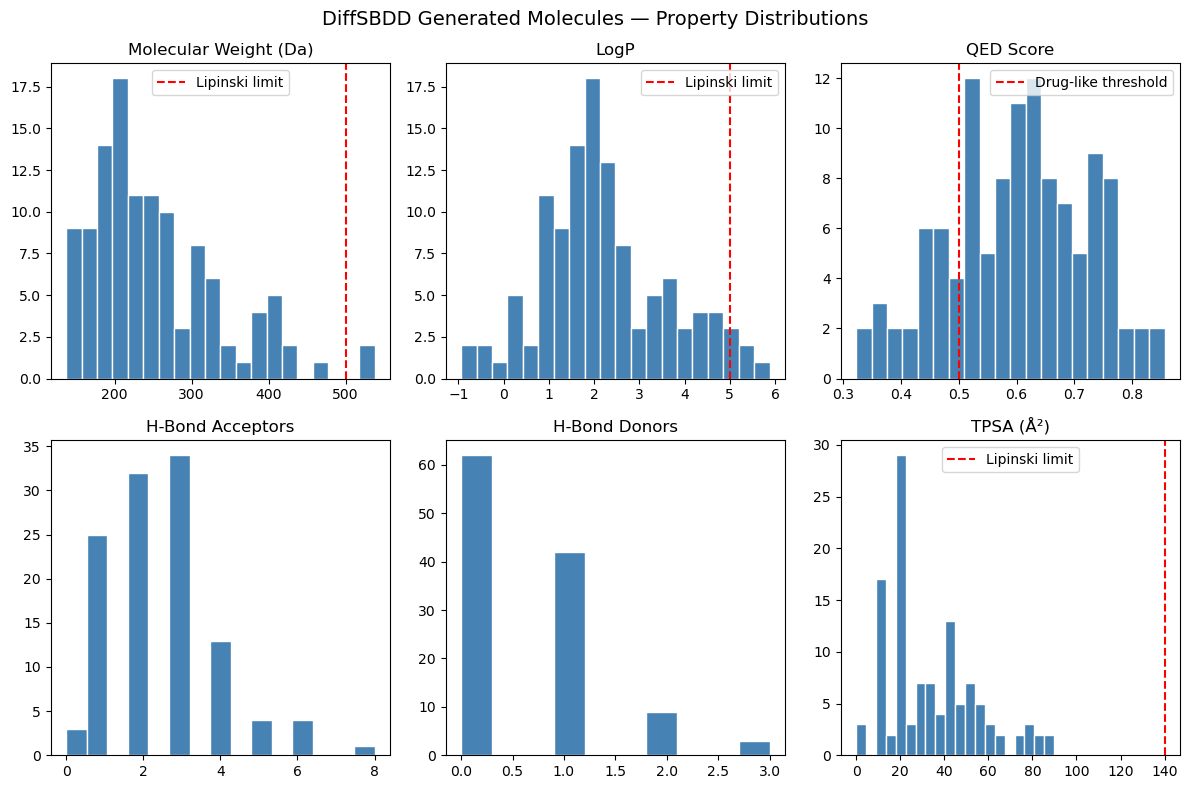

Saved to figures/


In [133]:
import matplotlib.pyplot as plt                    # library for creating plots and charts

# Create a grid of 6 subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# figsize=(12,8) = width 12 inches, height 8 inches

# Main title for the entire figure
fig.suptitle('DiffSBDD Generated Molecules — Property Distributions', fontsize=14)

# --- MW histogram ---
# bins=20 = divide data into 20 equal ranges
# edgecolor='white' = white borders between bars for clarity
axes[0,0].hist(df['MW'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Molecular Weight (Da)')
axes[0,0].axvline(500, color='red', linestyle='--', label='Lipinski limit')
# axvline = vertical dashed red line showing Lipinski maximum (500 Da)
axes[0,0].legend()

# --- LogP histogram ---
# LogP = lipophilicity: negative = hydrophilic, positive = lipophilic
axes[0,1].hist(df['LogP'], bins=20, color='steelblue', edgecolor='white')
axes[0,1].set_title('LogP')
axes[0,1].axvline(5, color='red', linestyle='--', label='Lipinski limit')
# Lipinski maximum LogP = 5
axes[0,1].legend()

# --- QED histogram ---
# QED = 0 to 1, higher = more drug-like
# most marketed drugs have QED > 0.5
axes[0,2].hist(df['QED'], bins=20, color='steelblue', edgecolor='white')
axes[0,2].set_title('QED Score')
axes[0,2].axvline(0.5, color='red', linestyle='--', label='Drug-like threshold')
axes[0,2].legend()

# --- HBA histogram ---
# HBA = hydrogen bond acceptors, Lipinski max = 10
axes[1,0].hist(df['HBA'], bins=15, color='steelblue', edgecolor='white')
axes[1,0].set_title('H-Bond Acceptors')

# --- HBD histogram ---
# HBD = hydrogen bond donors, Lipinski max = 5
axes[1,1].hist(df['HBD'], bins=10, color='steelblue', edgecolor='white')
axes[1,1].set_title('H-Bond Donors')

# --- TPSA histogram ---
# TPSA < 140 Å² = good membrane permeability = drug can enter cells
axes[1,2].hist(df['TPSA'], bins=20, color='steelblue', edgecolor='white')
axes[1,2].set_title('TPSA (Å²)')
axes[1,2].axvline(140, color='red', linestyle='--', label='Lipinski limit')
axes[1,2].legend()

plt.tight_layout()   # automatically adjust spacing between subplots

# Save figure to figures folder
plt.savefig('figures/diffsbdd_property_distributions.png', dpi=150)
# dpi=150 = resolution (higher = better quality image)

plt.show()           # display the figure in notebook
print("Saved to figures/")

## 8. Reference A2A Known Actives

31 well-known A2A ligands used as reference for similarity analysis,
including antagonists (Caffeine, ZM241385, Istradefylline...) and 
agonists (NECA, CGS21680, Regadenoson...).

In [134]:
# Load A2A reference actives from SDF file
# Using sanitize=False to handle any problematic molecules
ref_suppl = Chem.SDMolSupplier(
    'data/a2a_drugs/ADORA2A-world.sdf',
    sanitize=True,
    removeHs=True
)

ref_mols = {}   # dictionary: {molecule name: RDKit mol object}
counter = 0     # counter for unnamed molecules

for mol in ref_suppl:
    if mol is None:
        continue    # skip molecules RDKit cannot parse
    
    # Try to get name from _Name property
    name = mol.GetProp('_Name').strip() if mol.HasProp('_Name') else ''
    
    # If name is empty, use counter
    if not name:
        name = f"A2A_Active_{counter}"
    
    ref_mols[name] = mol
    counter += 1

print(f"Reference A2A actives loaded: {len(ref_mols)}")
print("\nFirst 5 reference molecules:")
for name in list(ref_mols.keys())[:5]:
    print(f"  {name}")

Reference A2A actives loaded: 31

First 5 reference molecules:
  A2A_Active_0
  A2A_Active_1
  A2A_Active_2
  A2A_Active_3
  A2A_Active_4


## 9. Tanimoto Similarity Analysis

Tanimoto coefficient (Tc) measures molecular similarity using Morgan fingerprints:
- **Tc > 0.85** — same scaffold
- **Tc 0.4–0.7** — scaffold hop (similar pharmacophore)
- **Tc < 0.3** — novel chemotype

For each generated molecule, we calculate the maximum Tanimoto similarity 
against all 10 reference A2A actives.

In [135]:
from rdkit.Chem import DataStructs                               # Tanimoto similarity calculation
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator # Morgan fingerprint generator

# Create Morgan fingerprint generator
# Morgan fingerprints encode molecular structure as a bit vector
# radius=2 = considers atoms up to 2 bonds away (captures local chemical environment)
# fpSize=2048 = fingerprint length in bits (longer = more detailed but slower)
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

# Load reference fingerprints from ADORA2A-world.sdf
# This file contains 31 known A2A actives from ChEMBL/ZINC
# More comprehensive than manual SMILES list — covers diverse A2A chemotypes
ref_suppl = Chem.SDMolSupplier('data/a2a_drugs/ADORA2A-world.sdf')

ref_fps = {}    # dictionary: {molecule name: fingerprint}
counter = 0     # counter for unnamed molecules

for mol in ref_suppl:
    if mol is None:
        continue    # skip invalid molecules
    
    # Get molecule name — use counter if name is empty
    name = mol.GetProp('_Name').strip() if mol.HasProp('_Name') else ''
    if not name:
        name = f"A2A_Active_{counter}"   # auto-generate name if empty
    
    ref_fps[name] = morgan_gen.GetFingerprint(mol)  # compute and store fingerprint
    counter += 1

print(f"Reference fingerprints loaded: {len(ref_fps)}")

# Calculate Tanimoto similarity for each generated molecule
max_tanimotos = []    # stores highest similarity score per generated molecule
nearest_actives = []  # stores which reference molecule is most similar

for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)           # convert SMILES to molecule object
    if mol is None:
        max_tanimotos.append(None)          # invalid molecule — store None
        nearest_actives.append(None)
        continue
    
    gen_fp = morgan_gen.GetFingerprint(mol) # compute fingerprint for generated molecule
    
    # Compare generated molecule against all reference molecules
    best_score = 0    # track highest Tanimoto score found
    best_name = ''    # track which reference gave highest score
    
    for name, ref_fp in ref_fps.items():
        # Tanimoto = |A∩B| / |A∪B| — shared bits / total bits
        # 0 = completely different, 1 = identical
        tc = DataStructs.TanimotoSimilarity(gen_fp, ref_fp)
        if tc > best_score:
            best_score = tc     # update best score
            best_name = name    # update nearest reference
    
    max_tanimotos.append(round(best_score, 4))  # store best score
    nearest_actives.append(best_name)            # store nearest reference name

# Add Tanimoto results as new columns to dataframe
df['max_tanimoto'] = max_tanimotos
df['nearest_active'] = nearest_actives

print(f"Tanimoto calculated for {len(df)} molecules")
print(f"\nMean max Tanimoto: {df['max_tanimoto'].mean():.3f}")
print(f"Max Tanimoto: {df['max_tanimoto'].max():.3f}")
print(f"\nNearest active distribution:")
print(df['nearest_active'].value_counts())

Reference fingerprints loaded: 31
Tanimoto calculated for 116 molecules

Mean max Tanimoto: 0.123
Max Tanimoto: 0.243

Nearest active distribution:
nearest_active
A2A_Active_24    18
A2A_Active_14    14
A2A_Active_0     12
A2A_Active_3     10
A2A_Active_30     8
A2A_Active_12     8
A2A_Active_23     7
A2A_Active_5      6
A2A_Active_2      6
A2A_Active_6      4
A2A_Active_1      4
A2A_Active_10     4
A2A_Active_19     3
A2A_Active_9      3
A2A_Active_20     2
A2A_Active_28     2
A2A_Active_8      2
A2A_Active_26     1
A2A_Active_7      1
A2A_Active_22     1
Name: count, dtype: int64


In [136]:
# Update CSV with Tanimoto results
df.to_csv('results/diffsbdd_generated.csv', index=False)
print("CSV updated!")
print(f"\nTanimoto similarity summary:")
print(f"  Mean max Tanimoto: {df['max_tanimoto'].mean():.3f}")
print(f"  Min:  {df['max_tanimoto'].min():.3f}")
print(f"  Max:  {df['max_tanimoto'].max():.3f}")

CSV updated!

Tanimoto similarity summary:
  Mean max Tanimoto: 0.123
  Min:  0.063
  Max:  0.243


### Identical Molecules Check

Check if any generated molecule is identical to a known reference active (Tc = 1.0).

In [137]:
# Find molecules identical to a known reference active (Tanimoto = 1.0)
# Tc = 1.0 means the generated molecule is exactly the same as a known drug
# This tells us the model has perfectly learned that pharmacophore
identical = df[df['max_tanimoto'] == 1.0]   # filter rows where Tc = 1.0

print("Identical to reference:")
# Show only relevant columns — smiles would be too long
print(identical[['smiles', 'max_tanimoto', 'nearest_active']])
print(f"\nTotal identical: {len(identical)}")

Identical to reference:
Empty DataFrame
Columns: [smiles, max_tanimoto, nearest_active]
Index: []

Total identical: 0


## 10. Tanimoto Distribution Plot

Left: distribution of max Tanimoto values per generated molecule.
Right: which reference molecule each generated molecule is most similar to.

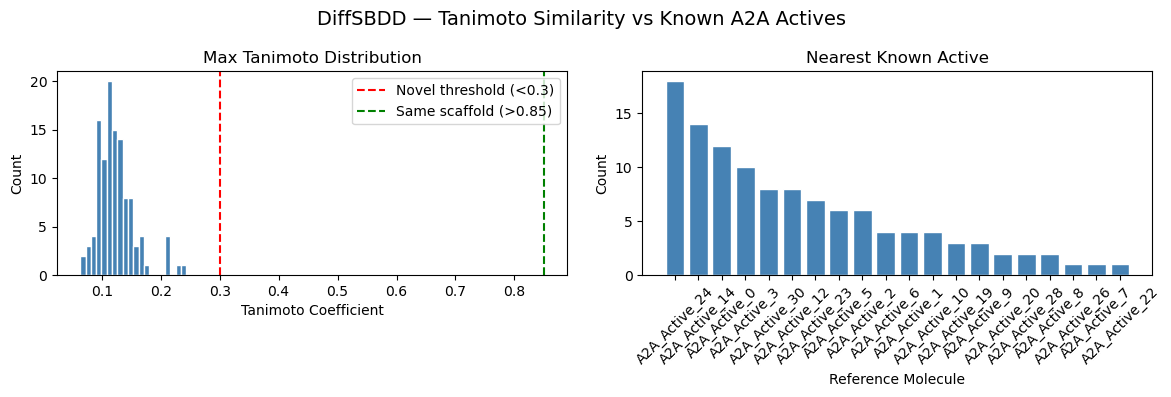

Saved to figures/


In [138]:
# Plot Tanimoto similarity distribution
# Two plots side by side: distribution + nearest active breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1 row, 2 columns side by side
fig.suptitle('DiffSBDD — Tanimoto Similarity vs Known A2A Actives', fontsize=14)

# --- Left: histogram of max Tanimoto values ---
# Each bar = how many molecules fall in that similarity range
# Shows how similar generated molecules are to known A2A actives overall
axes[0].hist(df['max_tanimoto'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Max Tanimoto Distribution')
axes[0].set_xlabel('Tanimoto Coefficient')        # x axis label
axes[0].set_ylabel('Count')                        # y axis label
axes[0].axvline(0.3, color='red', linestyle='--', label='Novel threshold (<0.3)')
# red line = below this = novel chemotype (very different from known drugs)
axes[0].axvline(0.85, color='green', linestyle='--', label='Same scaffold (>0.85)')
# green line = above this = essentially same molecule as known drug
axes[0].legend()

# --- Right: bar chart of nearest actives ---
# For each generated molecule, which known A2A drug is it most similar to?
# Tall bar = many generated molecules resemble that reference drug
nearest_counts = df['nearest_active'].value_counts()  # count per reference molecule
axes[1].bar(nearest_counts.index, nearest_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Nearest Known Active')
axes[1].set_xlabel('Reference Molecule')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)   # rotate x labels to avoid overlap

plt.tight_layout()   # automatically adjust spacing between subplots
plt.savefig('figures/diffsbdd_tanimoto.png', dpi=150)   # save high quality image
plt.show()
print("Saved to figures/")

## 11. Tanimoto Heatmap

Heatmap showing Tanimoto similarity between all generated molecules (rows) 
and all 31 known A2A reference actives (columns).

- **Dark/red color** = high similarity (similar to known drug)
- **Light/yellow color** = low similarity (novel chemotype)

Color scale is adjusted to the actual data range (not 0–1) to make 
differences between molecules visually clearer.

Similarity matrix shape: (116, 31)
(rows = generated molecules, columns = reference actives)
Max Tanimoto in matrix: 0.243


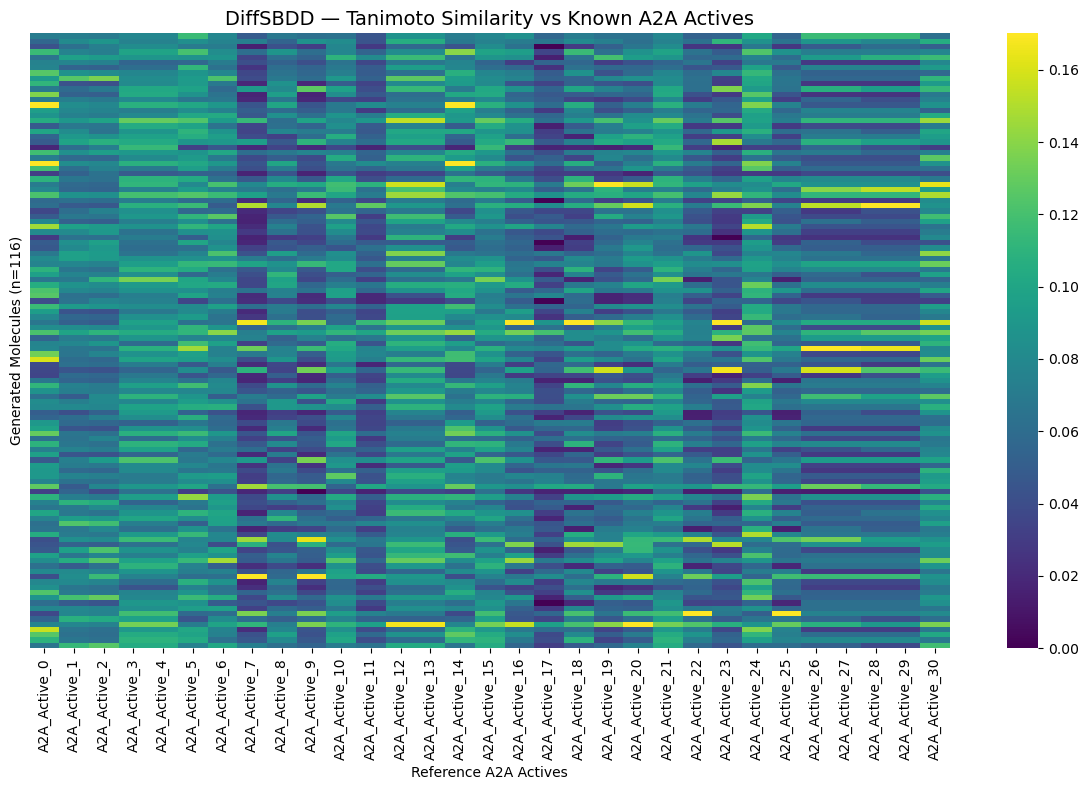

Saved! (color scale: 0 to 0.170)


In [139]:
import seaborn as sns   # seaborn = statistical visualization library, built on matplotlib

# Build similarity matrix: rows = generated molecules, columns = reference actives
# Each cell = Tanimoto similarity between that generated molecule and that reference
sim_matrix = []

for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)       # convert SMILES to molecule object
    if mol is None:
        continue                         # skip invalid molecules
    fp = morgan_gen.GetFingerprint(mol)  # compute fingerprint for generated molecule
    
    row = []                             # one row = one generated molecule
    for name, ref_fp in ref_fps.items():
        tc = DataStructs.TanimotoSimilarity(fp, ref_fp)  # Tc = |A∩B| / |A∪B|
        row.append(round(tc, 3))         # add similarity score for this reference
    sim_matrix.append(row)               # add complete row to matrix

# Convert list of lists to pandas DataFrame
# rows = generated molecules, columns = reference A2A actives
sim_df = pd.DataFrame(
    sim_matrix,
    columns=list(ref_fps.keys())         # column names = reference molecule names
)

print(f"Similarity matrix shape: {sim_df.shape}")
print("(rows = generated molecules, columns = reference actives)")

# Adjust color scale to actual data range
# vmax=1 makes everything pale because most values are <0.3
# Using 70% of max value increases contrast between cells
vmax = sim_df.max().max()
print(f"Max Tanimoto in matrix: {vmax:.3f}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    sim_df,
    cmap='viridis',          # dark purple=low similarity, yellow=high similarity
    vmin=0,                  # minimum = 0 (completely different molecules)
    vmax=vmax * 0.7,         # 70% of max — increases color contrast
    xticklabels=True,        # show reference molecule names on x axis
    yticklabels=False,       # hide row numbers — too many to show
    ax=ax
)
ax.set_title('DiffSBDD — Tanimoto Similarity vs Known A2A Actives', fontsize=14)
ax.set_xlabel('Reference A2A Actives')
ax.set_ylabel(f'Generated Molecules (n={len(sim_df)})')

plt.tight_layout()
plt.savefig('figures/diffsbdd_tanimoto_heatmap.png', dpi=150)
plt.show()
print(f"Saved! (color scale: 0 to {vmax*0.7:.3f})")

## 12. Results Summary

Final CSV saved with all calculated properties.
Full results in `results/diffsbdd_generated.csv`.

Key findings:
- 116 valid molecules generated by DiffSBDD
- 115/116 (99.1%) Lipinski compliant
- Mean QED: 0.602 — drug-like (above 0.5 threshold)
- Mean Tanimoto: 0.113 — novel chemotypes, low similarity to known A2A actives
- No molecule identical to known actives (max Tc = 0.147)

In [140]:
# Save final CSV with all properties
df.to_csv('results/diffsbdd_generated.csv', index=False)
print("Final CSV saved!")
print(f"\nSummary:")
print(f"Total molecules: {len(df)}")
print(f"Lipinski compliant: {len(df[df['Lipinski'] <= 1])} ({100*len(df[df['Lipinski'] <= 1])/len(df):.1f}%)")
print(f"Mean QED: {df['QED'].mean():.3f}")
print(f"Mean Tanimoto: {df['max_tanimoto'].mean():.3f}")
print(f"Identical to known active (Tc=1.0): {len(df[df['max_tanimoto']==1.0])}")

Final CSV saved!

Summary:
Total molecules: 116
Lipinski compliant: 115 (99.1%)
Mean QED: 0.602
Mean Tanimoto: 0.123
Identical to known active (Tc=1.0): 0


## 13. 2D Structure Visualization

Visual representation of 12 example molecules generated by DiffSBDD.
Each structure shows the 2D chemical graph of the molecule.

Loaded 12 molecules for visualization
Saved to figures/diffsbdd_example_molecules.png


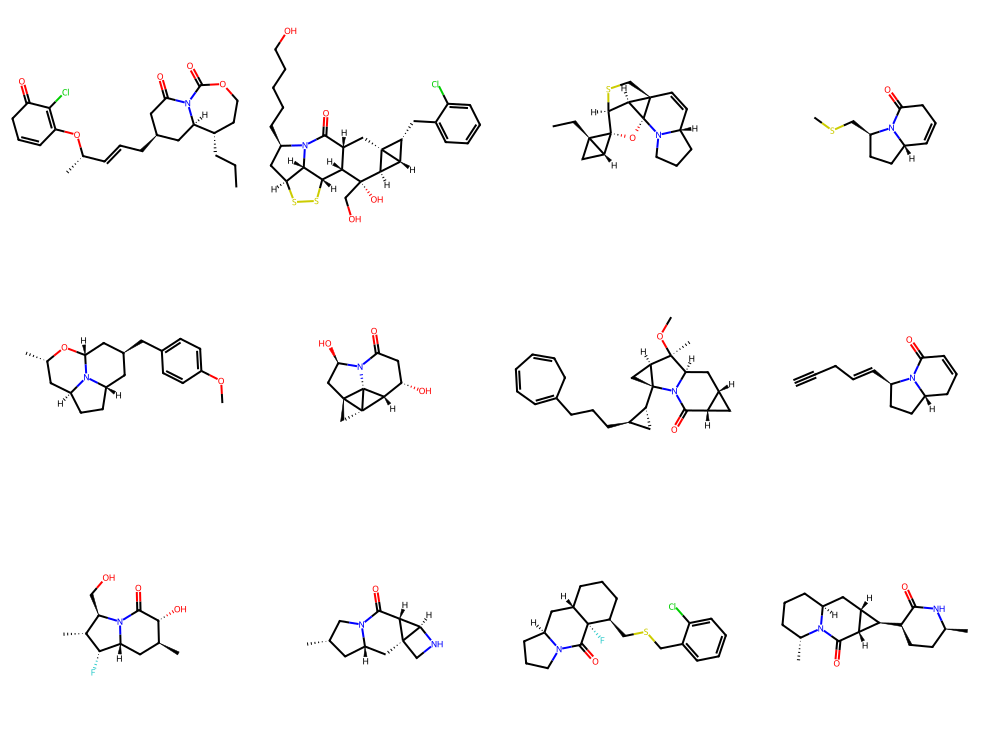

In [141]:
from rdkit.Chem import Draw    # RDKit module for drawing 2D molecular structures
from PIL import Image           # PIL = Python Imaging Library, for saving images

# Load molecules from DiffSBDD SDF file
# We already have clean_smiles — convert back to mol objects for visualization
viz_mols = []
for smi in clean_smiles[:12]:              # take first 12 molecules
    mol = Chem.MolFromSmiles(smi)          # convert SMILES to molecule object
    if mol is not None:
        viz_mols.append(mol)

print(f"Loaded {len(viz_mols)} molecules for visualization")

# Draw molecules in a 4x3 grid
img = Draw.MolsToGridImage(
    viz_mols[:12],           # first 12 molecules
    molsPerRow=4,            # 4 molecules per row → 3 rows total
    subImgSize=(250, 250),   # size of each molecule image in pixels
    returnPNG=False          # return PIL Image object (not raw PNG bytes)
)

# Save to figures folder
img.save('figures/diffsbdd_example_molecules.png')
print("Saved to figures/diffsbdd_example_molecules.png")
img   # display in notebook